In [73]:
import unicodedata
from IPython.display import display_markdown, display, Markdown, Latex
import json
from anthropic import Anthropic, HUMAN_PROMPT, AI_PROMPT
import requests
import networkx as nx
import matplotlib.pyplot as plt

In [74]:
def extract_osm_geodata(query):
    """
    Extracts geodata from OpenStreetMap using the Overpass API.
    Parameters:
    query (str): The Overpass API query string to execute.
    Returns:
    dict: GeoJSON data retrieved by the query.
    """
    # Define the Overpass API URL
    overpass_url = "https://lz4.overpass-api.de/api/interpreter"
    
    # Define the parameters for the GET request
    params = {'data': query}
    
    # Send a GET request to the Overpass API with the query
    response = requests.get(overpass_url, params=params)
    
    # Check if the request was successful
    if response.status_code == 200:
        return response.json()
    else:
        response.raise_for_status()

In [75]:
# Query to extract subway stations in Hamburg
query = """
[out:json];
area[name="Singapore"]->.searchArea;
relation["route"~"subway"](area.searchArea);
out meta;
>;
out body;
"""
singapore_mrt_data = extract_osm_geodata(query)

In [76]:
#pretty print json output
print(json.dumps(singapore_mrt_data, indent=2))

{
  "version": 0.6,
  "generator": "Overpass API 0.7.62.1 084b4234",
  "osm3s": {
    "timestamp_osm_base": "2024-10-19T11:18:12Z",
    "timestamp_areas_base": "2024-10-09T00:21:11Z",
    "copyright": "The data included in this document is from www.openstreetmap.org. The data is made available under ODbL."
  },
  "elements": [
    {
      "type": "relation",
      "id": 445764,
      "timestamp": "2024-08-10T05:08:06Z",
      "version": 69,
      "changeset": 155047031,
      "user": "nw0",
      "uid": 21829986,
      "members": [
        {
          "type": "node",
          "ref": 1547550796,
          "role": "stop"
        },
        {
          "type": "node",
          "ref": 1547519833,
          "role": "stop"
        },
        {
          "type": "node",
          "ref": 1547515539,
          "role": "stop"
        },
        {
          "type": "node",
          "ref": 1547412240,
          "role": "stop"
        },
        {
          "type": "node",
          "ref": 38587

In [77]:
def extract_route_elements(osm_data):
    """
    Extracts route elements from the OpenStreetMap data response.
    Parameters:
    osm_data (dict): The JSON response data from the Overpass API.
    Returns:
    list: A list of route elements containing 'tags' with 'route' information.
    """
    route_elements = [element for element in osm_data['elements'] if 'tags' in element and 'route' in element['tags']]
    return route_elements

# Call the function to extract route elements from the OpenStreetMap data for Hamburg's subway
route_elements =  extract_route_elements(singapore_mrt_data)

# Visualize the route of the list
route_elements[0]

{'type': 'relation',
 'id': 445764,
 'timestamp': '2024-08-10T05:08:06Z',
 'version': 69,
 'changeset': 155047031,
 'user': 'nw0',
 'uid': 21829986,
 'members': [{'type': 'node', 'ref': 1547550796, 'role': 'stop'},
  {'type': 'node', 'ref': 1547519833, 'role': 'stop'},
  {'type': 'node', 'ref': 1547515539, 'role': 'stop'},
  {'type': 'node', 'ref': 1547412240, 'role': 'stop'},
  {'type': 'node', 'ref': 385878948, 'role': 'stop'},
  {'type': 'node', 'ref': 385878107, 'role': 'stop'},
  {'type': 'node', 'ref': 385877670, 'role': 'stop'},
  {'type': 'node', 'ref': 209451110, 'role': 'stop'},
  {'type': 'node', 'ref': 209451088, 'role': 'stop'},
  {'type': 'node', 'ref': 6587737928, 'role': 'stop'},
  {'type': 'node', 'ref': 7684326278, 'role': 'stop'},
  {'type': 'node', 'ref': 209451013, 'role': 'stop'},
  {'type': 'node', 'ref': 6587699223, 'role': 'stop'},
  {'type': 'node', 'ref': 209390589, 'role': 'stop'},
  {'type': 'node', 'ref': 208527368, 'role': 'stop'},
  {'type': 'node', 'ref

In [78]:
def extract_node_elements(osm_data):
    """
    Extracts node elements from the OpenStreetMap data response.
    Parameters:
    osm_data (dict): The JSON response data from the Overpass API.
    Returns:
    dict: A dictionary where the keys are node IDs and the values are the corresponding node elements.
    """
    node_elements = {element['id']: element for element in osm_data['elements'] if element['type'] == 'node'}
    return node_elements

# Call the function to extract node elements from the OpenStreetMap data for Hamburg's subway
node_elements = extract_node_elements(singapore_mrt_data)

# Visualize the node_elements list
node_elements

{206477134: {'type': 'node',
  'id': 206477134,
  'lat': 1.3164515,
  'lon': 103.8829087,
  'tags': {'name': 'Aljunied',
   'name:en': 'Aljunied',
   'name:ms': 'Aljunied',
   'name:ta': 'அல்ஜூனிட்',
   'name:zh': '阿裕尼',
   'network': 'East West Line (EWL)',
   'operator': 'SMRT',
   'public_transport': 'station',
   'railway': 'station',
   'ref': 'EW9',
   'source': 'Kaart Ground Survey 2017',
   'station': 'subway',
   'subway': 'yes',
   'wheelchair': 'yes',
   'wikidata': 'Q3272290',
   'wikipedia': 'en:Aljunied MRT station'}},
 206493462: {'type': 'node',
  'id': 206493462,
  'lat': 1.3114669,
  'lon': 103.8713388,
  'tags': {'air_conditioning': 'no',
   'name': 'Kallang',
   'name:en': 'Kallang',
   'name:ms': 'Kallang',
   'name:ta': 'காலாங்',
   'name:zh': '加冷',
   'network': 'East West Line (EWL)',
   'operator': 'SMRT',
   'public_transport': 'station',
   'railway': 'station',
   'ref': 'EW10',
   'station': 'subway',
   'subway': 'yes',
   'wheelchair': 'yes',
   'wikidata

In [79]:
def extract_route_elements(osm_data):
    """
    Extracts route elements from the OpenStreetMap data response.
    Parameters:
    osm_data (dict): The JSON response data from the Overpass API.
    Returns:
    list: A list of route elements containing 'tags' with 'route' information.
    """
    route_elements = [element for element in osm_data['elements'] if 'tags' in element and 'route' in element['tags']]
    return route_elements

# Call the function to extract route elements from the OpenStreetMap data for Hamburg's subway
route_elements =  extract_route_elements(singapore_mrt_data)

# Visualize the route of the list
route_elements[0]

{'type': 'relation',
 'id': 445764,
 'timestamp': '2024-08-10T05:08:06Z',
 'version': 69,
 'changeset': 155047031,
 'user': 'nw0',
 'uid': 21829986,
 'members': [{'type': 'node', 'ref': 1547550796, 'role': 'stop'},
  {'type': 'node', 'ref': 1547519833, 'role': 'stop'},
  {'type': 'node', 'ref': 1547515539, 'role': 'stop'},
  {'type': 'node', 'ref': 1547412240, 'role': 'stop'},
  {'type': 'node', 'ref': 385878948, 'role': 'stop'},
  {'type': 'node', 'ref': 385878107, 'role': 'stop'},
  {'type': 'node', 'ref': 385877670, 'role': 'stop'},
  {'type': 'node', 'ref': 209451110, 'role': 'stop'},
  {'type': 'node', 'ref': 209451088, 'role': 'stop'},
  {'type': 'node', 'ref': 6587737928, 'role': 'stop'},
  {'type': 'node', 'ref': 7684326278, 'role': 'stop'},
  {'type': 'node', 'ref': 209451013, 'role': 'stop'},
  {'type': 'node', 'ref': 6587699223, 'role': 'stop'},
  {'type': 'node', 'ref': 209390589, 'role': 'stop'},
  {'type': 'node', 'ref': 208527368, 'role': 'stop'},
  {'type': 'node', 'ref

In [80]:
def create_route_graph(route_elements, node_elements):
    """
    Creates a graph of routes with stop nodes and edges between consecutive stops.
    Parameters:
    route_elements (list): A list of route elements containing 'members' and 'tags'.
    node_elements (dict): A dictionary of node elements with their IDs as keys.
    Returns:
    nx.Graph: A NetworkX graph object representing the routes and stop nodes.
    """
    # Create a graph object
    G = nx.Graph()

    for route in route_elements:
        stop_nodes = [member for member in route['members'] if 'stop' in member['role']]
        
        # Add nodes to the graph
        for node in stop_nodes:
            ref = node['ref']
            if ref in node_elements:
                # if ref has tags, then proceed
                if 'tags' in node_elements[ref]:
                    node_data = node_elements[ref]
                    name = node_data['tags'].get('name', str(ref))
                    colour = route['tags'].get('colour', '#808080')  # Default gray color if no color is defined
                
                G.add_node(ref, pos=(node_data['lon'], node_data['lat']), name=name, colour=colour)
        
        # Add edges between consecutive stop nodes
        for i in range(len(stop_nodes) - 1):
            G.add_edge(stop_nodes[i]['ref'], stop_nodes[i + 1]['ref'])
    
    return G

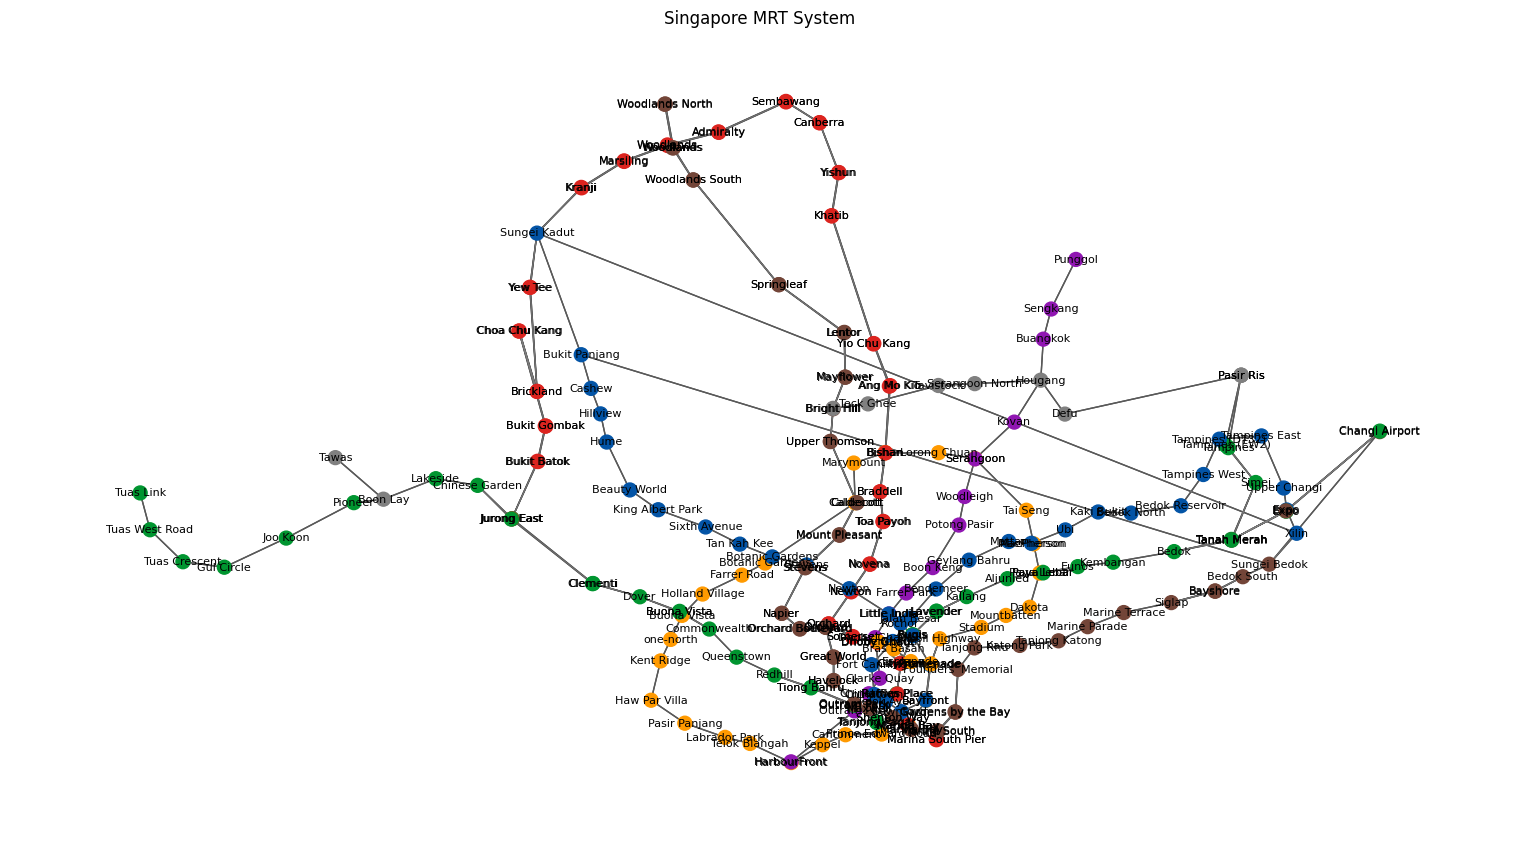

In [81]:

def visualize_graph(G, title):
    """
    Visualizes the graph with nodes and edges.
    Parameters:
    G (nx.Graph): A NetworkX graph object representing the routes and stop nodes.
    Returns:
    None: Displays a plot of the graph.
    """
    # Set the plot size
    plt.figure(figsize=(15, 8))  # Adjust the width and height as needed

    # Draw the graph with nodes and edges
    pos = nx.get_node_attributes(G, 'pos')
    node_labels = nx.get_node_attributes(G, 'name')
    node_colours = list(nx.get_node_attributes(G, 'colour').values())
    nx.draw(G, pos, with_labels=True, labels=node_labels, node_size=100, node_color=node_colours, font_size=8)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.7)
    plt.title(title)
    plt.show()

# Create the graph for the Hamburg subway system
singapore_mrt_graph = create_route_graph(route_elements, node_elements)

# Visualize the graph with a title
visualize_graph(singapore_mrt_graph, 'Singapore MRT System')

In [86]:
#pretty print node_elements
print(singapore_mrt_graph)

#print first element in node_elements
print(type(singapore_mrt_graph))

Graph with 251 nodes and 264 edges
<class 'networkx.classes.graph.Graph'>


In [83]:
import folium

# Initialize the map centered on Singapore
singapore_map = folium.Map(location=[1.3521, 103.8198], zoom_start=12)

In [84]:
# Assuming singapore_mrt_graph is a NetworkX graph with nodes having 'lat' and 'lon' attributes
for node, data in singapore_mrt_graph.nodes(data=True):
    folium.Marker(
        location=[data['lat'], data['lon']],
        popup=node,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(singapore_map)

for u, v, data in singapore_mrt_graph.edges(data=True):
    folium.PolyLine(
        locations=[
            [singapore_mrt_graph.nodes[u]['lat'], singapore_mrt_graph.nodes[u]['lon']],
            [singapore_mrt_graph.nodes[v]['lat'], singapore_mrt_graph.nodes[v]['lon']]
        ],
        color='blue'
    ).add_to(singapore_map)

# Save the map to an HTML file
singapore_map.save('singapore_mrt_map.html')

KeyError: 'lat'